# ¿Qué es el Análisis Exploratorio de Datos?
El Análisis Exploratorio de Datos es una técnica utilizada en la Ciencia de Datos para entender y analizar los datos de un conjunto de datos antes de realizar un análisis más detallado. Es una etapa crucial en cualquier proyecto de Ciencia de Datos, ya que permite identificar patrones, relaciones, anomalías y posibles errores en los datos.

El objetivo del EDA es obtener una comprensión profunda de los datos, lo que a su vez ayuda a formular hipótesis y definir las variables relevantes para el análisis posterior. Además, el EDA puede ayudar a seleccionar las técnicas de análisis más adecuadas y establecer una línea de base para la precisión del modelo.

# Importación de librerías y conjunto de datos
Para realizar el EDA, vamos a utilizar la librería seaborn de Python, que contiene varios conjuntos de datos interesantes para practicar el análisis de datos. En este caso, vamos a utilizar el conjunto de datos "tips", que contiene información sobre el importe de la cuenta, la propina y otras características relacionadas con las propinas en los restaurantes.

Comencemos importando las librerías necesarias y cargando el conjunto de datos en un dataframe de pandas:

In [1]:
import seaborn as sns
import pandas as pd

tips = sns.load_dataset("tips")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
dt = pd.read_csv('/content/drive/MyDrive/Hotel Reservations.csv')

# Exploración general del conjunto de datos
El primer paso en el EDA es familiarizarse con el conjunto de datos. Para hacerlo, podemos utilizar algunas funciones simples de pandas:



# Shape y Types
Utilizar el método `shape` nos dá un preview del tamaño del dataset mientras que el método `dtypes` nos permite entender con que tipo de datos estámos lidiando:

In [2]:
tips.shape

(244, 7)

In [3]:
tips.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [6]:
dt.shape

(36275, 19)

In [7]:
dt.dtypes

Booking_ID                               object
no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
room_type_reserved                       object
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
market_segment_type                      object
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                           object
dtype: object

# Head y Tail
Podemos utilizar las funciones `head` y `tail` de pandas para ver las primeras y últimas filas del conjunto de datos, respectivamente:

In [15]:
tips.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


In [13]:
tips.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


Esto nos dará una idea de cómo se ven los datos y qué tipo de información contienen.


## Descripción general del conjunto de datos
Podemos obtener una descripción general del conjunto de datos utilizando la función `describe` de pandas:

In [16]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [17]:
tips.describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,2.998279,1.383638,1.00,2.0000,2.900,3.5625,10.00
size,244.0,2.569672,0.951100,1.00,2.0000,2.000,3.0000,6.00


In [20]:
tips.describe(include=['category'])

,sex,smoker,day,time
count,244,244,244,244
unique,2,2,4,2
top,Male,No,Sat,Dinner
freq,157,151,87,176


In [21]:
tips.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
total_bill,244.0,NaN,NaN,NaN,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,NaN,NaN,NaN,2.998279,1.383638,1.0,2.0,2.9,3.5625,10.0
sex,244,2,Male,157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoker,244,2,No,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,244,4,Sat,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,244,2,Dinner,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,244.0,NaN,NaN,NaN,2.569672,0.9511,1.0,2.0,2.0,3.0,6.0


In [19]:
dt.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


Esto nos dará algunas estadísticas básicas sobre las variables numéricas en el conjunto de datos, como el número de observaciones, la media, la desviación estándar, los valores mínimo y máximo y los percentiles.


## Información de las columnas
Podemos obtener información sobre las columnas en el conjunto de datos utilizando la función `info` de pandas:

In [22]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [23]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

Esto nos dará información sobre el número de valores no nulos en cada columna y el tipo de datos de cada columna.

In [24]:
tips.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [25]:
tips.isnull()

,total_bill,tip,sex,smoker,day,time,size
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
239,False,False,False,False,False,False,False
240,False,False,False,False,False,False,False
241,False,False,False,False,False,False,False
242,False,False,False,False,False,False,False


# Visualización de datos
La visualización de datos es una parte importante del EDA, ya que nos permite ver patrones y relaciones que podrían no ser evidentes en una tabla de datos. seaborn ofrece una amplia gama de herramientas para la visualización de datos.

## Diagrama de dispersión (scatter plot)
Una forma común de visualizar la relación entre dos variables numéricas es mediante un diagrama de dispersión. seaborn hace que sea fácil crear un diagrama de dispersión utilizando la función scatterplot:

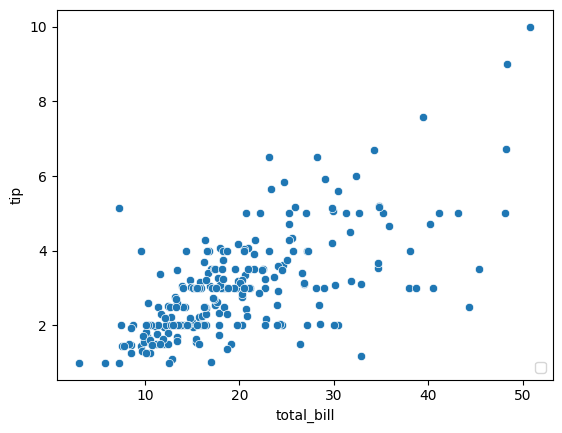

In [33]:
import matplotlib.pyplot as plt
sns.scatterplot(x="total_bill", y="tip", data=tips) #, hue='day', palette='viridis')
plt.legend(loc='lower right')

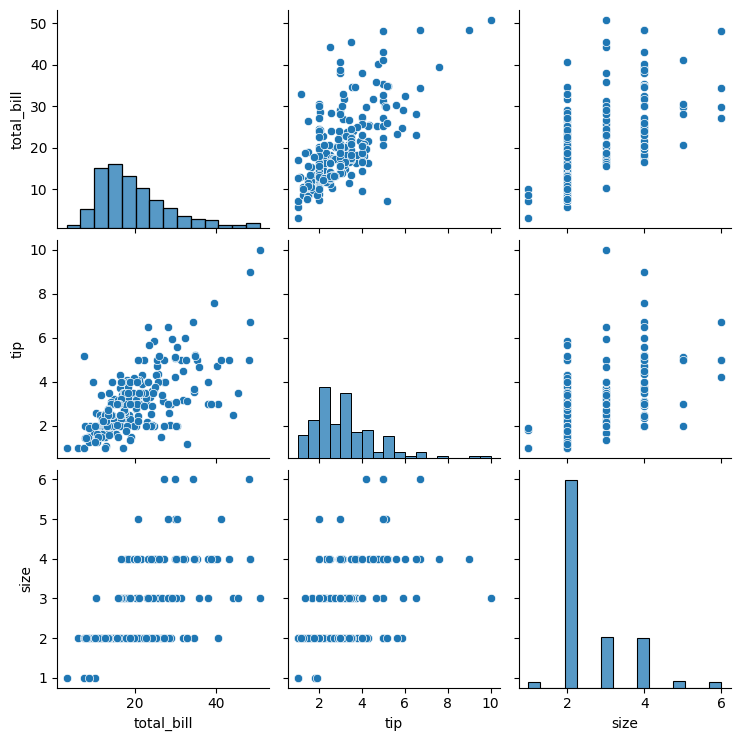

In [35]:
sns.pairplot(tips) #, hue='day')

Las paletas de colores más populares pueden variar según la comunidad y las tendencias actuales en visualización de datos. Aquí tienes una lista de algunas paletas populares en ese momento:

Viridis
Plasma
Inferno
Magma
Cividis
Twilight
RdBu
RdYlBu
RdBu_r
Blues
Greens
Oranges
Reds
PuBu
BuPu
PuBuGn
YlOrBr
YlOrRd
YlGnBu
YlGn
Spectral
PiYG
PRGn
BrBG
Accent
Set1
Set2
Set3
Pastel1
Pastel2



Esto nos dará un diagrama de dispersión de la relación entre el importe de la cuenta y la propina. Podemos ver que hay una relación positiva entre ambas variables, lo que significa que a medida que aumenta el importe de la cuenta, también lo hace la propina.

## Diagrama de barras (bar plot)
Otra forma común de visualizar los datos es mediante un diagrama de barras, que se utiliza para mostrar la distribución de una variable categórica. seaborn hace que sea fácil crear un diagrama de barras utilizando la función `countplot`:

<Axes: xlabel='day', ylabel='count'>

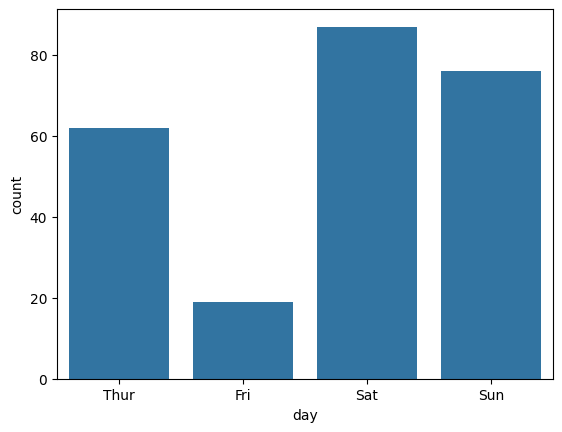

In [36]:
sns.countplot(x="day", data=tips)

Esto nos dará un diagrama de barras de la distribución de la variable "day" en el conjunto de datos. Podemos ver que el número de observaciones es mayor los sábados y domingos.

## Histograma (histogram)
Un histograma es una forma común de visualizar la distribución de una variable numérica. seaborn hace que sea fácil crear un histograma utilizando la función `histplot`:

<Axes: xlabel='total_bill', ylabel='Count'>

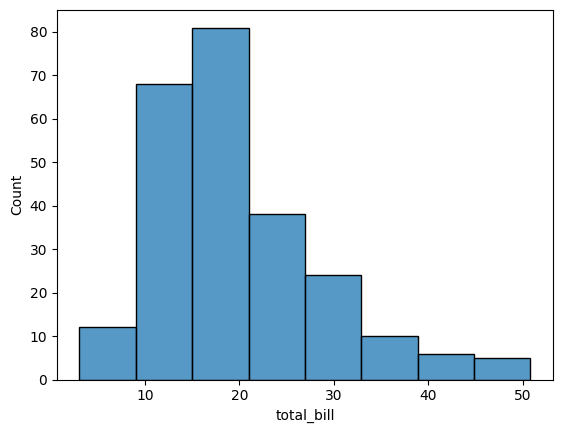

In [41]:
sns.histplot(x="total_bill", bins = 8, data=tips)

Esto nos dará un histograma de la distribución del importe de la cuenta en el conjunto de datos. Podemos ver que la mayoría de las observaciones se encuentran entre $10 y $20.

# Análisis de correlación
El análisis de correlación es una parte importante del EDA, ya que nos permite ver la relación entre las variables numéricas en el conjunto de datos. Una forma común de analizar la correlación es mediante el cálculo de la matriz de correlación y la visualización de la misma mediante un mapa de calor.

## Matriz de correlación (correlation matrix)
Podemos calcular la matriz de correlación utilizando la función `corr` de pandas:

In [47]:
tipsNumerico = tips.select_dtypes(include=['float', 'int64'])

In [49]:
tipsNumerico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   size        244 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 5.8 KB


In [50]:
tipsNumerico.head()

,total_bill,tip,size
0,16.99,1.01,2
1,10.34,1.66,3
2,21.01,3.50,3
3,23.68,3.31,2
4,24.59,3.61,4


In [48]:
tipsNumerico.corr()

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


Esto nos dará una matriz de correlación que muestra la correlación entre todas las variables numéricas en el conjunto de datos.

## Mapa de calor (heatmap)
Podemos visualizar la matriz de correlación utilizando un mapa de calor. seaborn hace que sea fácil crear un mapa de calor utilizando la función `heatmap`:

<Axes: >

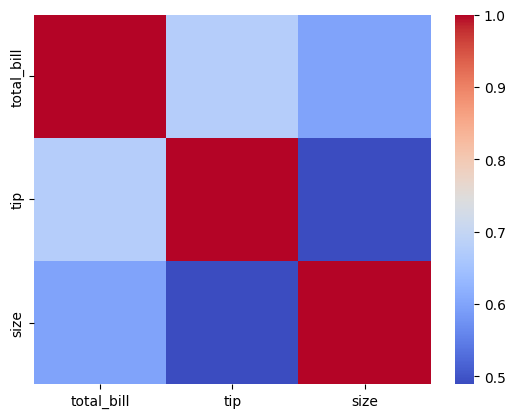

In [52]:
sns.heatmap(tipsNumerico.corr(), cmap='coolwarm')

Esto nos dará un mapa de calor que muestra la correlación entre todas las variables numéricas en el conjunto de datos. Los valores más oscuros indican una correlación más fuerte, mientras que los valores más claros indican una correlación más débil.

# Ejemplo de Análisis Exploratorio de Datos
A continuación, utilizaremos el conjunto de datos iris incluido en scikit-learn para realizar un ejemplo de Análisis Exploratorio de Datos.

## Importando librerías y cargando el conjunto de datos
Comenzamos importando las librerías necesarias y cargando el conjunto de datos:

In [53]:
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [58]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

En este ejemplo, utilizamos `load_iris` de scikit-learn para cargar el conjunto de datos `iris`. Luego, creamos un objeto `DataFrame` de pandas con los datos y agregamos una columna para el objetivo (target) del conjunto de datos.

## Explorando el conjunto de datos
Ahora, podemos comenzar a explorar el conjunto de datos utilizando las funciones que hemos discutido anteriormente:

In [54]:
# Explorando el conjunto de datos
print("Filas y columnas\n")
print(df.shape)
print("\nTipos de Dato\n")
print(df.dtypes)
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

Filas y columnas

(150, 5)

Tipos de Dato

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1 

Esto nos dará una idea general del conjunto de datos. Podemos ver que el conjunto de datos tiene 150 observaciones y 5 variables. No hay valores nulos en el conjunto de datos.

In [57]:
df.shape

(150, 5)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


## Visualizando los datos
A continuación, podemos utilizar algunas de las visualizaciones discutidas anteriormente para explorar los datos:

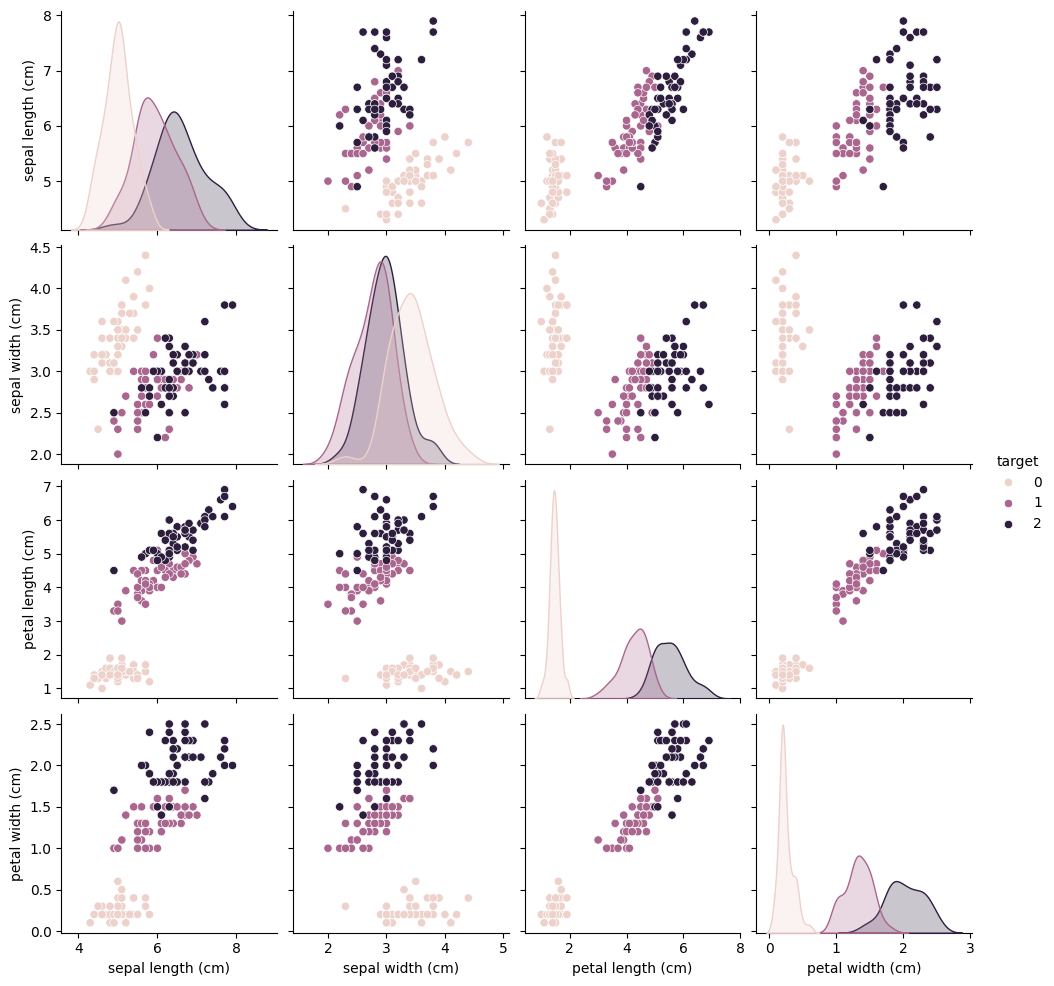

In [59]:
# Visualizando los datos
sns.pairplot(df, hue='target')


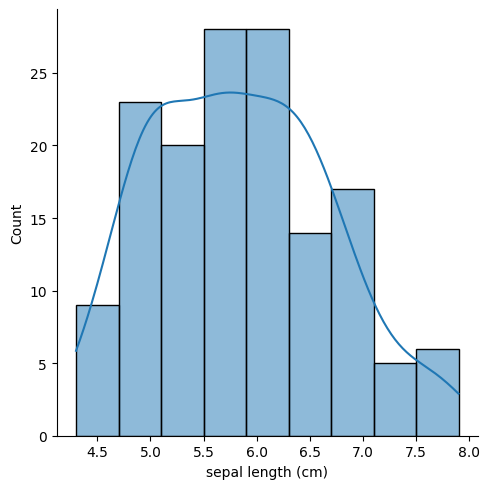

In [60]:
sns.displot(df, x='sepal length (cm)', kde=True)

<ipython-input-61-c9bc87f51dce>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


<Axes: xlabel='target', ylabel='count'>

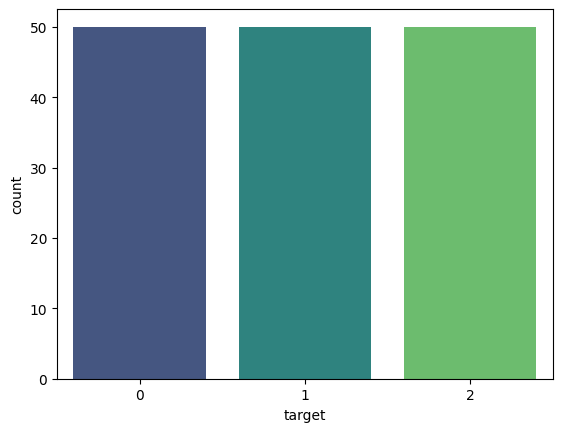

In [61]:
sns.countplot(x='target', data=df, palette='viridis')

La primera visualización utiliza `pairplot` para mostrar la relación entre todas las variables numéricas en el conjunto de datos, con diferentes colores para cada objetivo (target). La segunda visualización utiliza `displot` para mostrar la distribución de la variable 'sepal length (cm)'. La tercera visualización utiliza `countplot` para mostrar la distribución del objetivo (target).

## Análisis de correlación
Finalmente, podemos utilizar `corr` de pandas y `heatmap` de seaborn para analizar la correlación entre las variables numéricas en el conjunto de datos:

<Axes: >

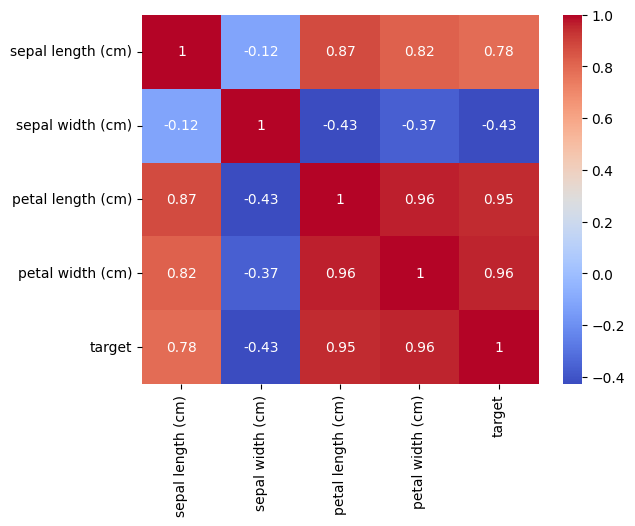

In [62]:
# Análisis de correlación
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

Esto nos dará un mapa de calor que muestra la correlación entre todas las variables numéricas en el conjunto de datos. Podemos ver que hay una correlación positiva entre el largo del sépalo y el largo del pétalo, así como una correlación negativa entre el largo del sépalo y el ancho del pétalo.